> **Open in Google Colab.** The next cell installs `coptpy`. The bundled free license is size-limited but covers this case. Then run *Runtime > Run all*.


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy matplotlib


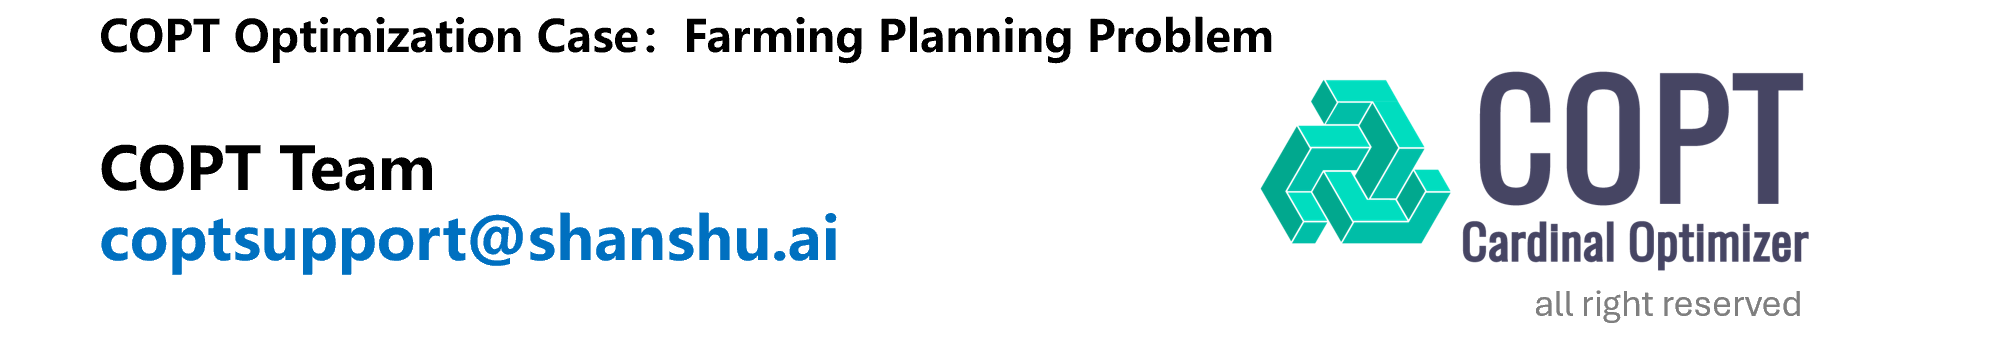

# Farming Planning Problem Code Implementation

## Steps to Model and Solve Farming Planning Problem Using COPT

1. **Import COPT-Python API** `coptpy`

2. **Add Model Data**
    - Import parameter list (including the information of various resources, etc.)

3. **Create the COPT Environment and COPT Model**

4. **Add three core components of COPT Model**
    - **Add Decision Variables**：
        - $x_c$: Hectares of crop $c$ planted (hectares)
        - $V^P$: Number of long-term laborers hired (persons)
        - $V_t^T$: Hours of short-term laborers hired in month $t$ (hours)
        - $s_c$: Sales quantity of crop $c$
        - $z_b$: Proportion occupied by the $b$-th food combination scheme
    - **Set Objective Function**：Maximize the revenue under the constraints being met;
    - **Add Constraints**：
        - Land resource demand
        - Labor demand
        - Water resource demand
        - Household consumption demand

5. **Solve**

6. View and interpret the **results**

## Import COPT-Python API

In [4]:
import coptpy as cp
from coptpy import COPT

import matplotlib.pyplot as plt

## Add Model Data

In [6]:
# Import the proportion of land area required by various crops each month
crops_land = [[1,    1,    1,    0,    0,    0],
              [1,    1,    1,    0,    0,    0],
              [1,    1,    1,    0.5,  0,    0],
              [1,    1,    1,    1,    0,    0],
              [1,    0,    0.25, 1,    0.25, 0],
              [0,    0,    0,    1,    1,    0],
              [0,    0,    0,    1,    1,    0.75],
              [0,    0,    0,    1,    1,    1],
              [0,    0,    0,    1,    1,    1],
              [0,    0,    0,    1,    0.5,  1],
              [0.5,  0.25, 0.5,  0.75, 0,    0.75],
              [1,    1,    1,    0,    0,    0]]

# Import available land area
L = 10

# Import the working hours required by various crops each month
crops_labor = [[14,  6,   41,  0,   0,   0],
               [4,   6,   40,  0,   0,   0],
               [8,   6,   40,  40,  0,   0],
               [8,   128, 155, 40,  0,   0],
               [137, 0,   19,  72,  34,  0],
               [0,   0,   0,   16,  40,  0],
               [0,   0,   0,   12,  57,  136],
               [0,   0,   0,   16,  64,  120],
               [0,   0,   0,   8,   35,  96],
               [0,   0,   0,   46,  9,   56],
               [19,  60,  89,  34,  0,   48],
               [11,  6,   37,  0,   0,   0]]

# Import the working hours required by various crops each month
labors = [160, 160, 184, 176, 168, 176, 176, 176, 176, 168, 176, 176]

# Import the water quantity required by various crops each month
crops_water = [[0.535, 0.438, 0.452, 0,     0,     0],
               [0.802, 0.479, 0.507, 0,     0,     0],
               [0.556, 0.505, 0.640, 0.197, 0,     0],
               [0.059, 0.142, 0.453, 0.494, 0,     0],
               [0,     0,     0,     1.047, 0.303, 0],
               [0,     0,     0,     1.064, 0.896, 0],
               [0,     0,     0,     1.236, 1.318, 0.120],
               [0,     0,     0,     0.722, 0.953, 0.241],
               [0,     0,     0,     0.089, 0.205, 0.525],
               [0,     0,     0,     0,     0,     0.881],
               [0.373, 0.272, 0,     0,     0,     0.865],
               [0.456, 0.335, 0.305, 0,     0,     0]]

# Import food combinations
bundles = [[0, 1.20, 0, 0, 0.15, 0.25],
           [0, 0.73, 0, 0, 1.50, 0.25],
           [0, 0.70, 0, 0, 1.00, 0.75]]

# Import crop yields
crops_yield = [1.50, 1.00, 6.00, 1.50, 1.75, 6.00]

# Import crop prices
crops_price = [1000, 2000, 750, 3500, 700, 800]

# Import number of family laborers
V_F = 1.5

# Import wages of three types of laborers
r_F = 4144
r_P = 5180
r_T = 4

# Import annual water resource usage
W = 50

# Import monthly water resource usage
w_t = 5

# Import water fees
p_W = 10

# Obtain number of crop types
num_crops = len(crops_land[0])

# Obtain types of food combinations
num_bundle = len(bundles)

## Preprocess the data

In [8]:
crops_land_trans = [[] for _ in range(48)]
for i in range(12):
    for j in  range(num_crops):
        if crops_land[i][j] == int(crops_land[i][j]):
            for k in range(4):
                crops_land_trans[i * 4 + k].append(crops_land[i][j])
        elif crops_land[i][j] == 0.25:
            if crops_land[i - 1][j] == 1:
                crops_land_trans[i * 4].append(1)
                crops_land_trans[i * 4 + 1].append(0)
                crops_land_trans[i * 4 + 2].append(0)
                crops_land_trans[i * 4 + 3].append(0)
            else:
                crops_land_trans[i * 4].append(0)
                crops_land_trans[i * 4 + 1].append(0)
                crops_land_trans[i * 4 + 2].append(0)
                crops_land_trans[i * 4 + 3].append(1)
        elif crops_land[i][j] == 0.5:
            if crops_land[i - 1][j] == 1:
                crops_land_trans[i * 4].append(1)
                crops_land_trans[i * 4 + 1].append(1)
                crops_land_trans[i * 4 + 2].append(0)
                crops_land_trans[i * 4 + 3].append(0)
            else:
                crops_land_trans[i * 4].append(0)
                crops_land_trans[i * 4 + 1].append(0)
                crops_land_trans[i * 4 + 2].append(1)
                crops_land_trans[i * 4 + 3].append(1)
        elif crops_land[i][j] == 0.75:
            if crops_land[i - 1][j] == 1:
                crops_land_trans[i * 4].append(1)
                crops_land_trans[i * 4 + 1].append(1)
                crops_land_trans[i * 4 + 2].append(1)
                crops_land_trans[i * 4 + 3].append(0)
            else:
                crops_land_trans[i * 4].append(0)
                crops_land_trans[i * 4 + 1].append(1)
                crops_land_trans[i * 4 + 2].append(1)
                crops_land_trans[i * 4 + 3].append(1)
display(crops_land_trans)

[[1, 1, 1, 0, 0, 0],
 [1, 1, 1, 0, 0, 0],
 [1, 1, 1, 0, 0, 0],
 [1, 1, 1, 0, 0, 0],
 [1, 1, 1, 0, 0, 0],
 [1, 1, 1, 0, 0, 0],
 [1, 1, 1, 0, 0, 0],
 [1, 1, 1, 0, 0, 0],
 [1, 1, 1, 0, 0, 0],
 [1, 1, 1, 0, 0, 0],
 [1, 1, 1, 1, 0, 0],
 [1, 1, 1, 1, 0, 0],
 [1, 1, 1, 1, 0, 0],
 [1, 1, 1, 1, 0, 0],
 [1, 1, 1, 1, 0, 0],
 [1, 1, 1, 1, 0, 0],
 [1, 0, 1, 1, 0, 0],
 [1, 0, 0, 1, 0, 0],
 [1, 0, 0, 1, 0, 0],
 [1, 0, 0, 1, 1, 0],
 [0, 0, 0, 1, 1, 0],
 [0, 0, 0, 1, 1, 0],
 [0, 0, 0, 1, 1, 0],
 [0, 0, 0, 1, 1, 0],
 [0, 0, 0, 1, 1, 0],
 [0, 0, 0, 1, 1, 1],
 [0, 0, 0, 1, 1, 1],
 [0, 0, 0, 1, 1, 1],
 [0, 0, 0, 1, 1, 1],
 [0, 0, 0, 1, 1, 1],
 [0, 0, 0, 1, 1, 1],
 [0, 0, 0, 1, 1, 1],
 [0, 0, 0, 1, 1, 1],
 [0, 0, 0, 1, 1, 1],
 [0, 0, 0, 1, 1, 1],
 [0, 0, 0, 1, 1, 1],
 [0, 0, 0, 1, 1, 1],
 [0, 0, 0, 1, 1, 1],
 [0, 0, 0, 1, 0, 1],
 [0, 0, 0, 1, 0, 1],
 [0, 0, 0, 1, 0, 1],
 [0, 0, 0, 1, 0, 1],
 [1, 0, 1, 1, 0, 1],
 [1, 1, 1, 0, 0, 0],
 [1, 1, 1, 0, 0, 0],
 [1, 1, 1, 0, 0, 0],
 [1, 1, 1, 0, 0, 0],
 [1, 1, 1, 0,

## Create the COPT Environment and COPT Model

In [10]:
env = cp.Envr()
model = env.createModel()

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## Add three core components of COPT Model

### Add Decision Variables
- $x_c$: Hectares of crop $c$ planted (hectares)
- $V^P$: Number of long-term laborers hired (persons)
- $V_t^T$: Hours of short-term laborers hired in month $t$ (hours)
- $s_c$: Sales quantity of crop $c$
- $z_b$: Proportion occupied by the $b$-th food combination scheme
> All the above decision variables are non-negative continuous variables (laborer quantities can be decimals, considered as averages)

In [12]:
crops = model.addVars(num_crops, lb=0, nameprefix='crop')
V_P = model.addVar(lb=0, name='V_P')
V_T = model.addVars(12, lb=0, nameprefix='V_T')
sales = model.addVars(num_crops, lb=0, nameprefix='sales')
z_b = model.addVars(num_bundle, lb=0, nameprefix='z_b')

### Set Objective Function
1. Income from the sale of crops
$$
    INP = \sum_c p_c \cdot s_c
$$

In [14]:
INP = cp.quicksum(crops_price[i] * sales[i] for i in range(num_crops))

2. Expenditure of hired laborers
    - family laborers
    $$
        OP_{labor_1} = r^F \cdot V^F
    $$
    - long-term laborers
    $$
        OP_{labor_2} = r^P \cdot V^P
    $$
    - short-term laborers
    $$
        OP_{labor_3} = r^T \cdot \sum_t V_t^t
    $$

In [16]:
OP_labor_1 = r_F * V_F
OP_labor_2 = r_P * V_P
OP_labor_3 = r_T * cp.quicksum(V_T)

3. Expenditure of water
$$
    OP_{water} = p^W \cdot \sum_{t, c} R_{t, c} \cdot x_c
$$

In [18]:
OP_water = p_W * cp.quicksum(cp.quicksum(crops_water[j][i] * crops[i] for j in range(12)) for i in range(num_crops))

The objective is to maximize total revenue.
$$
    \max INP - OP_{labor_1} - OP_{labor_2} - OP_{labor_3} - OP_{water}
$$

In [20]:
model.setObjective(INP - OP_labor_1 - OP_labor_2 - OP_labor_3 - OP_water, sense=COPT.MAXIMIZE)

### Add Constraints
**1. Land Resource Demand (by Month):**
Crop land usage varies by month. The model uses parameter $l_{t,c}$ to describe the proportion of the entire month that crop $c$ occupies land in month $t$.

- When $l_{t,c}=1$, it indicates that crop $c$ occupies land throughout the entire period of month $t$;
- When $l_{t,c}<1$, it indicates that the crop only occupies land for part of that month. This situation typically corresponds to crops being sown in the middle of the month, or land being released after harvest in the middle of the month and becoming available for planting other crops.

$$
    \sum_c l_{t, c} \cdot x_c \leq L, \, \forall \, t
$$

In [22]:
model.addConstrs((cp.quicksum(crops_land_trans[j][i] * crops[i] for i in range(num_crops)) <= L for j in range(48)), nameprefix='land')

**2. Labor Demand (by Month):**

The model uses $v_{t,c}$ to represent the unit area labor demand of crop $c$ in month $t$ (hours/hectare). When the planting area of crop $c$ is $x_c$, its labor demand in month $t$ is $v_{t,c} \cdot x_c$, and the total labor demand for all crops in that month is $\sum_c v_{t,c} \cdot x_c$.

Labor supply consists of three components: family laborers $V^F$ (fixed quantity), long-term hired laborers $V^P$, and the working hours of short-term hired laborers $V_t^T$ (quantity determined by decisions). Family laborers and long-term hired laborers can each provide up to $h_t$ hours of work in month $t$. Therefore, the total working hours provided by family and long-term laborers in that month is $h_t \cdot (V^F + V^P)$. To ensure that labor supply can cover production demand within month $t$, the following monthly labor constraint must be satisfied:
$$
    \sum_c v_{t, c} \cdot x_c \leq h_t (V^F + V^P) + V_t^T, \, \forall \, t
$$

In [24]:
model.addConstrs(cp.quicksum(crops_labor[j][i] * crops[i] for i in range(num_crops)) <= labors[j] * (V_F + V_P) + V_T[j] for j in range(12))

**3. Water Resource Demand (by Month and Annually):**

Water resource availability is simultaneously constrained by both monthly and annual limitations. The model uses $R_{t,c}$ to represent the unit area water usage of crop $c$ in month $t$ (liters/hectare). When the planting area of crop $c$ is $x_c$, its water usage in month $t$ is $R_{t,c} \cdot x_c$, and the total water usage for all crops in that month is $\sum_c R_{t,c} \cdot x_c$.

- There exists a maximum available upper limit $w_t$ for water resources in each month. In any given month, the total water usage of all crops must not exceed the water resource limit for that month, resulting in the monthly water resource constraint:
$$
    \sum_c R_{t,c} \cdot x_c \le w_t, \qquad \forall t
$$

- The annual total water resource upper limit is $W$. The sum of water usage across all months and crops must not exceed this annual upper limit, resulting in the annual water resource constraint:
$$
    \sum_{t,c} R_{t,c} \cdot x_c \le W
$$

$$
    \sum_c R_{t, c} \cdot x_c \leq w_t, \, \forall \, t \quad \text{(Month demand)}
$$
$$
    \sum_{t, c} R_{t, c} \cdot x_c \leq W \quad \text{(Year demand)}
$$

In [26]:
model.addConstrs(cp.quicksum(crops_water[j][i] * crops[i] for i in range(num_crops)) <= w_t for j in range(12))
model.addConstr(cp.quicksum(cp.quicksum(crops_water[j][i] * crops[i] for i in range(num_crops)) for j in range(12)) <= W, name='water_year')

<coptpy.Constraint: water_year>

**4. Household Consumption Demand:**

Harvested crops need to be allocated between household consumption and market sales. For each crop, its annual yield must simultaneously satisfy household food consumption demand and market sales demand, thereby forming the following yield balance constraint:
$$
    y_c \cdot x_c = \sum_b d_{c, b} \cdot z_b + s_c, \, \forall \, c
$$

Household food consumption is achieved through several food combination schemes. The sum of the usage proportions of these combination schemes throughout the year is 1:
$$
    \sum_b z_b = 1
$$

In [28]:
model.addConstrs(crops_yield[i] * crops[i] == cp.quicksum(bundles[j][i] * z_b[j] for j in range(num_bundle)) + sales[i] for i in range(num_crops))
model.addConstr(cp.quicksum(z_b) == 1)

<coptpy.Constraint: >

## Solve

In [30]:
model.solve()

Model fingerprint: c25a7a61

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Maximizing an LP problem

The original problem has:
    80 rows, 28 columns and 268 non-zero elements
The presolved problem has:
    10 rows, 34 columns and 123 non-zero elements

Starting the simplex solver using up to 8 threads

Problem info:
    Range of matrix coefficients:    [1e-01,5e+00]
    Range of rhs coefficients:       [3e+00,1e+03]
    Range of bound coefficients:     [2e+01,1e+03]
    Range of cost coefficients:      [1e+00,1e+02]

Method   Iteration           Objective  Primal.NInf   Dual.NInf        Time
Dual-I           0   -1.0000000000e+00            3           1       0.03s
Dual-I           5    0.0000000000e+00            0           0       0.03s
Dual             5    1.4401282497e+04            5           0       0.04s


## Retrieve Results

In [32]:
if model.status == COPT.OPTIMAL:
    print(f'The optimal total profit is {round(model.objVal, 2)} yuan')
    print('The production arrangement is as follows:')
    variables = model.getVars()
    len_var = len(variables)
    
    data = [['Index', 'Crop name','Plant(ton)', 'Harvest(ton)', 'Sale(ton)', 'Consumption(ton)']]
    crop_name = ['Wheat', 'Beans', 'Onions', 'Cotton', 'Maize', 'Tomatoes']
    for i in range(num_crops):
        data.append([i, 
                     round(variables[i].x, 2), 
                     crop_name[i],
                     round(variables[i].x * crops_yield[i], 2),
                     round(variables[i + num_crops + 13].x, 2),
                     round(variables[i].x * crops_yield[i] - variables[i + num_crops + 13].x, 2)])
    
    print("{:^10} {:^10} {:^10} {:^10} {:^10} {:^10}".format(data[0][0], data[0][1], data[0][2], data[0][3], data[0][4], data[0][5]))
    for item in data[1:]:
        print("{:^10} {:^15} {:^15} {:^15} {:^15} {:^15}".format(item[0], item[1], item[2], item[3], item[4], item[5]))

    month_in_English = ['Jan.', 'Feb.', 'Mar.', 'Apr.', 'May.', 'Jun.', 'Jul.', 'Aug.', 'Sept.', 'Oct.', 'Nov.', 'Dec.']
    print()
    print(f'Hire long-term laborers {round(variables[num_crops].x, 2)}')
    print()
    print('The situation of hiring short-term laborers is as follows:')
    for i in range(1, 7):
        print("{:^5} {:^15} {:^5} {:^15}".format(f'{month_in_English[i - 1]}', f'{round(variables[num_crops + i].x, 2)} hours', f'{month_in_English[i + 5]}', f'{round(variables[num_crops + i + 6].x, 2)} hours'))

else:
    print('Fail to find the optimal solution.')

The optimal total profit is 39008.95 yuan
The production arrangement is as follows:
  Index    Crop name  Plant(ton) Harvest(ton) Sale(ton)  Consumption(ton)
    0            0.0            Wheat            0.0             0.0             0.0      
    1            4.4            Beans            4.4             3.2             1.2      
    2           2.08           Onions           12.45           12.45            0.0      
    3           3.53           Cotton           5.29            5.29             0.0      
    4           0.09            Maize           0.15             0.0            0.15      
    5            4.4          Tomatoes          26.39           26.14           0.25      

Hire long-term laborers 0.0

The situation of hiring short-term laborers is as follows:
Jan.     0.0 hours    Jul.   381.27 hours  
Feb.     0.0 hours    Aug.   325.62 hours  
Mar.     0.0 hours    Sept.  189.38 hours  
Apr.   761.67 hours   Oct.   157.27 hours  
May.    44.29 hours   Nov.   51

## Case Expansion: Adjusting Annual Maximum Water Usage to Observe Solution Trends
Change the annual maximum water usage from a fixed value of $50$ to a gradual adjustment within the range of $40$ to $50$, thereby analyzing the impact of solutions as maximum water usage varies.

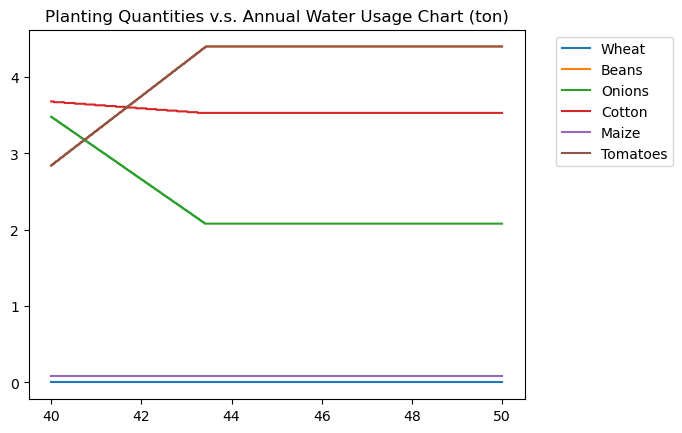

In [34]:
# Run the model multiple times to examine the variation range

cnt = 1001
x_range = [40 + i * 0.01 for i in range(cnt)]
solution = [[] for _ in range(num_crops)]
crop_name = ['Wheat', 'Beans', 'Onions', 'Cotton', 'Maize', 'Tomatoes']

model.setParam(COPT.Param.Logging, False)

for x in x_range:
    model.getConstrByName('water_year').ub = x
    model.solve()
    variables = model.getVars()
    for i in range(num_crops):
        solution[i].append(round(variables[i].x, 2))

for i in range(num_crops):
    plt.plot(x_range, solution[i], label=crop_name[i])
plt.legend(bbox_to_anchor=(1.05, 1))
plt.title('Planting Quantities v.s. Annual Water Usage Chart (ton)')
plt.show()
    
# Restore to prevent impact on subsequent operations
model.getConstrByName(f'water_year').ub = W

<font color=#B9C78D>
<b>Tips: Change the upper bound of constraint</b>
</font>   

In this context, since we need to adjust the value of a certain parameter multiple times, rebuilding the model each time would consume significant human and computational resources. Therefore, we choose to directly modify the constraint conditions of the existing model. We can use the function `model.getConstrByName()` to locate the corresponding constraint object based on the constraint name, and then directly change the upper bound value of that constraint through the `ub` property.

## Case Expansion: Adjusting Total Available Land Area to Observe Solution Trends
Change the total available land area from a fixed value of $10$ to a gradual adjustment within the range of $8$ to $12$, thereby analyzing the impact of solutions as total available land area varies.

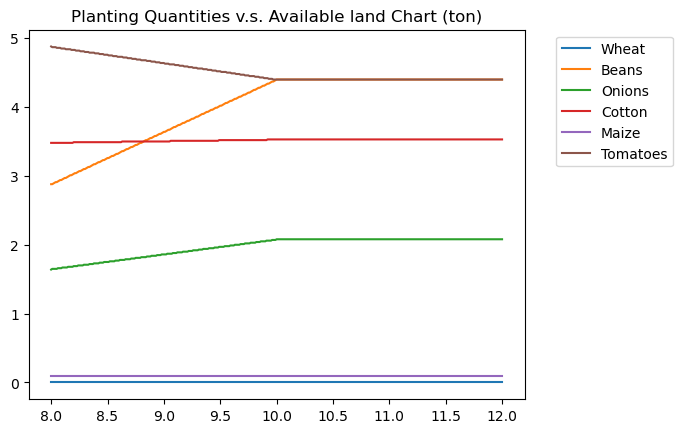

In [37]:
# Run the model multiple times to examine the variation range

cnt = 401
x_range = [8 + i * 0.01 for i in range(cnt)]
solution = [[] for _ in range(num_crops)]

model.setParam(COPT.Param.Logging, False)

for x in x_range:
    for i in range(12):
        model.getConstrByName(f'land({i})').ub = x
    model.solve()
    variables = model.getVars()
    for i in range(num_crops):
        solution[i].append(round(variables[i].x, 2))

for i in range(num_crops):
    plt.plot(x_range, solution[i], label=crop_name[i])
plt.legend(bbox_to_anchor=(1.05, 1))
plt.title('Planting Quantities v.s. Available land Chart (ton)')
plt.show()

# Restore to prevent impact on subsequent operations
for i in range(12):
    model.getConstrByName(f'land({i})').ub = L